References:
- *Sams Teach Yourself R in 24 Hours*: Hour 4 for introduction to lists and data frames
- *Sams Teach Yourself R in 24 Hours*: Hour 11 for data manipulation with data frames (not used)
- https://www.datanovia.com/learn/programming/data-wrangling/


# Review
Vectors hold a single data type.
- Functions applied to the vector give summary statistics (`fivenum`, `mean`, `sd`, etc.) and graphs (`boxplot`, `hist`, etc.).
- Subsetting vectors give subvectors.

[1] 2.857143

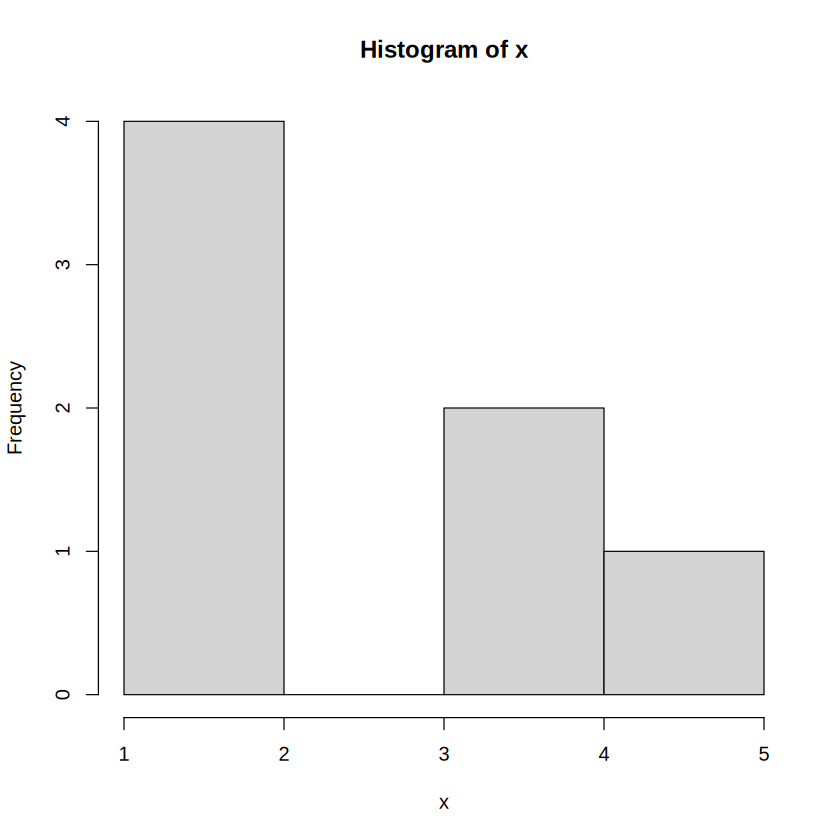

In [2]:
# Assign a vector of numeric values to x.
x <- c(NA, 1,2,2,2,4,4,5, NA, NA)

# Get mean of vector x
mean(x, na.rm = T)

# Graph histogram of x
hist(x)

# Checking for `NA`
Use `is.na(x)` to check if `x` is `NA` since equality-checking gives the undesired result:

In [3]:
x <- 3
x == NA

[1] NA

In [4]:
is.na(x)

[1] FALSE

This lets us remove missing-value entries from a vector:

In [7]:
# Remove missing-value entries
x <- c(NA, 1,2,2,2,4,4,5, NA, NA)
is.na(x) # Checks if each entry is NA or not, one-by-one, outputting a vector of T's & F's

x[is.na(x)] # Keeps the NA entires of x
x[!is.na(x)] # 'Removes' the NA entires of x
# ! is used to take the compliments of boolean values, "flips" the T/F values

[1]  TRUE FALSE FALSE FALSE FALSE FALSE FALSE FALSE  TRUE  TRUE

[1]  1  2  2  2  4  4  5 NA NA

# Lists

Lists are like vectors but store many data types. They are created via `list` constructor:

In [13]:
# Create list of 4 elements
meals <- list('apple', 'orange', 6, 1:3)
meals

# Find length of list via length()
length(meals)

# Add names to list
names(meals) <- c('breakfast', 'lunch', 'day', 'prices')
meals
# Create named list directly
meals <- list(breakfast = 'apple', lunch = 'orange', day = 6, prices = 1:3)
meals

[[1]]
[1] "apple"

[[2]]
[1] "orange"

[[3]]
[1] 6

[[4]]
[1] 1 2 3

[1] 4

$breakfast
[1] "apple"

$lunch
[1] "orange"

$day
[1] 6

$prices
[1] 1 2 3

$breakfast
[1] "apple"

$lunch
[1] "orange"

$day
[1] 6

$prices
[1] 1 2 3

In [17]:
# Retrieve sub-list via [], retrieve entry via [[]]
meals[1]
meals[[1]]

$breakfast
[1] "apple"

[1] "apple"

In [18]:
# Retrieve entry of named list via $
meals$breakfast

[1] "apple"

In [21]:
# Write to a new column of `meals`
meals$dinner <- 'eggs'
meals$brunch <- c(meals$breakfast, meals$lunch)
meals

$breakfast
[1] "apple"

$lunch
[1] "orange"

$day
[1] 6

$prices
[1] 1 2 3

$dinner
[1] "eggs"

$brunch
[1] "apple"  "orange"

Combine lists via `c`. This also lets you append to an existing list.

Why use lists?
- Statistical test printouts are pretty-printed lists.
- Data frames is a named list that holds vectors of the same length.

# Data frames
Data frame is a named list that holds vectors of the same length. It is displayed as a table.

In [22]:
# Create a data frame
weather <- data.frame(
	  Day   = c("Saturday", "Sunday", "Monday", "Tuesday", "Wednesday"),
    Date  = c("Jul 4", "Jul 5", "Jul 6", "Jul 7", "Jul 8"),
    TempF = c(75, 86, 83, 83, 87)
)
weather

Day,Date,TempF
<chr>,<chr>,<dbl>
Saturday,Jul 4,75
Sunday,Jul 5,86
Monday,Jul 6,83
Tuesday,Jul 7,83
Wednesday,Jul 8,87


- Writing one index specifies a column of the data frame. (Won't be used much)
- Writing $ selects the named column of the data frame.
- Writing two indices specifies the row and column indices of a specific entry.

In [23]:
# Select entry 'Jul 6'
weather[3,2]

[1] "Jul 6"

In [ ]:
# Select column 2 directly; remains data frame:
weather[,2] # This doesn't remain a dataframe, but does get the appropriate column
weather[2] # Remains as a dataframe

In [ ]:
# Select column name via `$`; becomes a vector:
weather$Date

In [ ]:
# Select column 2 via 2 indices; becomes a vector:


We can mutate existing entries or create new columns by direct assignment:

In [25]:
# Change date of 3rd row
weather[3,2] <- 'Jul 5'
# Add column of Celsius temperature
weather#Temp <- (weather$TempF - 32)*5/9
weather

Day,Date,TempF
<chr>,<chr>,<dbl>
Saturday,Jul 4,75
Sunday,Jul 5,86
Monday,Jul 5,83
Tuesday,Jul 7,83
Wednesday,Jul 8,87


Day,Date,TempF
<chr>,<chr>,<dbl>
Saturday,Jul 4,75
Sunday,Jul 5,86
Monday,Jul 5,83
Tuesday,Jul 7,83
Wednesday,Jul 8,87


# Match a set of values: `%in%`
For larger number of matches, use %in% over chaining equality checks `==` with OR `|`


In [ ]:
# Filter for: rows which are on the weekends
weather[weather$Day $%in% c("Saturday", "Sunday"), ]

 # Conditional statements
`ifelse(condition, A, B)` checks a logical statement `condition`. If the condition is true, `A` is executed. If it is false, `B` is executed.


In [27]:
weather$Feels <- ifelse(weather$Temp > 85, "Hot", "Cool")
weather

Day,Date,TempF,Feels
<chr>,<chr>,<dbl>,<chr>
Saturday,Jul 4,75,Cool
Sunday,Jul 5,86,Hot
Monday,Jul 5,83,Cool
Tuesday,Jul 7,83,Cool
Wednesday,Jul 8,87,Hot


`ifelse` is a vectorized version of the usual if-else statement in R, and leverages parallel computing to speed up its execution.

# Sorting
`order(weather$TempF)` returns row positions that put `TempF` in ascending order, and the `decreasing = TRUE` option gives the opposite order.

In [ ]:
weather[order(weather$Temp, decreasing = T)]

# Group summary

In [28]:
# Find mean temperature after grouping by "Feels" column
aggregate(TempF ~ Feels, data = weather, FUN = mean)

Feels,TempF
<chr>,<dbl>
Cool,80.33333
Hot,86.50000


Here `FUN` is the function used on each sub-group.

# Large datasets

## Import and view data
Import and export data with `read.csv` and `write.csv`.

Take a glimpse at your large dataset with `head` or `tail`

In [31]:
grades <- read.csv("https://manctsui.github.io/datasets/grades.csv")
head(grades, 3)

,Student_ID,Name,Age,Gender,Grade,Exam.1,Exam.2,Exam.3
,<int>,<chr>,<int>,<chr>,<chr>,<int>,<int>,<int>
1,2368,Frank Allen,18,Male,A,78,73,76
2,9746,David Caldwell,22,Female,C,81,50,42
3,8926,Erica Martinez,16,Female,D,89,78,85


In [ ]:
# Add column with average exam grade
grades$avg_grade <- (grades$Exam.1 + grades$Exam.2 + grades$Exam.3)/3
grades

In [ ]:
# Export with write.csv
